In [ ]:
import pandas as pd
import numpy as np

In [ ]:
url = "https://raw.githubusercontent.com/vaastav/Fantasy-Premier-League/master/data/2023-24/gws/merged_gw.csv"
df = pd.read_csv(url)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29725 entries, 0 to 29724
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   name                        29725 non-null  object 
 1   position                    29725 non-null  object 
 2   team                        29725 non-null  object 
 3   xP                          29725 non-null  float64
 4   assists                     29725 non-null  int64  
 5   bonus                       29725 non-null  int64  
 6   bps                         29725 non-null  int64  
 7   clean_sheets                29725 non-null  int64  
 8   creativity                  29725 non-null  float64
 9   element                     29725 non-null  int64  
 10  expected_assists            29725 non-null  float64
 11  expected_goal_involvements  29725 non-null  float64
 12  expected_goals              29725 non-null  float64
 13  expected_goals_conceded     297

In [ ]:
df.sort_values(['name','GW'],inplace=True)

minutes → (if playing) goals + assists + bonus → total_points

In [ ]:
df['points_last3_avg']=df.groupby('name')['total_points'].transform(lambda x:x.shift(1).rolling(3).mean())
df['points_last5_avg']=df.groupby('name')['total_points'].transform(lambda x:x.shift(1).rolling(5).mean())
df['minutes_last5_avg']=df.groupby('name')['minutes'].transform(lambda x:x.shift(1).rolling(5).mean())
df['goals_last5_avg']=df.groupby('name')['goals_scored'].transform(lambda x:x.shift(1).rolling(5).mean())
df['assists_last5_avg']=df.groupby('name')['assists'].transform(lambda x:x.shift(1).rolling(5).mean())
df['bps_last5_avg']=df.groupby('name')['bps'].transform(lambda x:x.shift(1).rolling(5).mean())

In [ ]:
df.drop(columns=[
    'assists','bonus','clean_sheets','element','fixture','goals_scored','kickoff_time','own_goals',
    'penalties_missed','penalties_saved','red_cards','round',
    'selected','team_a_score','team_h_score','transfers_in','minutes',
    'transfers_out','ict_index','yellow_cards','starts','bps','saves','goals_conceded'
],inplace=True)

In [ ]:
df[df['name']=='Erling Haaland']['xP']

,xP
445,5.5
1064,8.0
1713,7.8
2410,10.8
3123,11.0
3840,10.0
4616,5.7
5369,3.8
6098,5.0
6829,9.2


In [ ]:
print(df[['points_last3_avg','points_last5_avg',
          'goals_last5_avg','assists_last5_avg',
          'minutes_last5_avg','bps_last5_avg']].isna().sum())

points_last3_avg     2599
points_last5_avg     4323
goals_last5_avg      4323
assists_last5_avg    4323
minutes_last5_avg    4323
bps_last5_avg        4323
dtype: int64


In [ ]:
cutoff=30
train_data=df[df['GW']<=cutoff]
test_data=df[df['GW']>cutoff]

In [ ]:
train_data.shape

(22269, 23)

In [ ]:
test_data.shape

(7456, 23)

In [ ]:
type(train_data)

pandas.core.frame.DataFrame

In [ ]:
train_data['total_points'].mean()

np.float64(1.0734204499528492)

In [ ]:
test_data['total_points'].mean()

np.float64(0.98806330472103)

In [ ]:
train_data['value'].mean()

np.float64(48.39283308635323)

In [ ]:
test_data['value'].mean()

np.float64(47.71875)

In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22269 entries, 228 to 22259
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   name                        22269 non-null  object 
 1   position                    22269 non-null  object 
 2   team                        22269 non-null  object 
 3   xP                          22269 non-null  float64
 4   creativity                  22269 non-null  float64
 5   expected_assists            22269 non-null  float64
 6   expected_goal_involvements  22269 non-null  float64
 7   expected_goals              22269 non-null  float64
 8   expected_goals_conceded     22269 non-null  float64
 9   influence                   22269 non-null  float64
 10  opponent_team               22269 non-null  int64  
 11  threat                      22269 non-null  float64
 12  total_points                22269 non-null  int64  
 13  transfers_balance           22269 

In [ ]:
drop=['name','GW','total_points','expected_goals_conceded','xP','influence','expected_goals','expected_assists','creativity','expected_goal_involvements','threat']

xTrain=train_data.drop(columns=drop)
yTrain=train_data['total_points']

xTest=test_data.drop(columns=drop)
yTest=test_data['total_points']


In [ ]:
xTrain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22269 entries, 228 to 22259
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   opponent_team      22269 non-null  int64  
 1   transfers_balance  22269 non-null  int64  
 2   value              22269 non-null  int64  
 3   was_home           22269 non-null  bool   
 4   minutes_last5_avg  18084 non-null  float64
 5   goals_last5_avg    18084 non-null  float64
 6   assists_last5_avg  18084 non-null  float64
 7   bps_last5_avg      18084 non-null  float64
dtypes: bool(1), float64(4), int64(3)
memory usage: 1.4 MB


In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,r2_score

model=xgb.XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
)

model.fit(xTrain,yTrain)
yPred=model.predict(xTest)

In [ ]:
print("MAE",mean_absolute_error(yTest,yPred))
print("RMSE",root_mean_squared_error(yTest,yPred))
print("R2",r2_score(yTest,yPred))

MAE 0.8707444071769714
RMSE 1.8996223211288452
R2 0.3107514977455139


,0
minutes_last5_avg,0.459657
transfers_balance,0.126519
value,0.122325
bps_last5_avg,0.087419
was_home,0.056384
assists_last5_avg,0.055492
opponent_team,0.049086
goals_last5_avg,0.043118


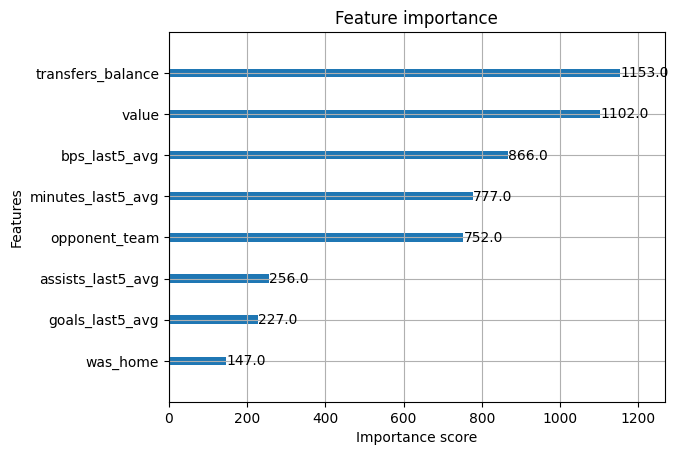

In [ ]:
xgb.plot_importance(model,max_num_features=15)
pd.Series(model.feature_importances_, index=list(xTrain.columns)).sort_values(ascending=False)


In [ ]:
baseline_pred = train_data.mean()
baseline_mae  = mean_absolute_error(train_data['total_points'], [baseline_pred] * len(train_data))
print("Baseline MAE:", baseline_mae)
print("Model MAE:   ", 0.87)

Baseline MAE: 1.4090625828347343
Model MAE:    0.87


In [ ]:
print("Target mean:", train_data['total_points'].mean())
print("Target std :", train_data['total_points'].std())
print("Target max :", train_data['total_points'].max())
print("Target min :", train_data['total_points'].min())

Target mean: 1.0734204499528492
Target std : 2.294753874815538
Target max : 23
Target min : -4


<class 'pandas.core.frame.DataFrame'>
Index: 22269 entries, 228 to 22259
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   xP                          22269 non-null  float64
 1   creativity                  22269 non-null  float64
 2   expected_assists            22269 non-null  float64
 3   expected_goal_involvements  22269 non-null  float64
 4   expected_goals              22269 non-null  float64
 5   expected_goals_conceded     22269 non-null  float64
 6   influence                   22269 non-null  float64
 7   opponent_team               22269 non-null  int64  
 8   threat                      22269 non-null  float64
 9   transfers_balance           22269 non-null  int64  
 10  value                       22269 non-null  int64  
 11  was_home                    22269 non-null  bool   
 12  points_last3_avg            19743 non-null  float64
 13  points_last5_avg            18084 non-null  float64
 14  minutes_last5_avg           18084 non-null  float64
 15  goals_last5_avg             18084 non-null  float64
 16  assists_last5_avg           18084 non-null  float64
 17  bps_last5_avg               18084 non-null  float64
dtypes: bool(1), float64(14), int64(3)
memory usage: 3.1 MB


i tried dropping xP its not the answer neither is tansfers_balance, i already dropped goals_conceded earlier, i dropped expected_goals_conceded and tried still teh same answer

In [ ]:
from scipy.stats import spearmanr

results = []

for gw in test['GW'].unique():
    gw_test = test[test['GW'] == gw].copy()
    gw_test['pred'] = model.predict(gw_test[features])

    # Spearman rank correlation: predicted vs actual
    corr, _ = spearmanr(gw_test['pred'], gw_test['total_points'])

    # Precision@5
    actual_top5  = set(gw_test.nlargest(5, 'total_points')['name'])
    pred_top5    = set(gw_test.nlargest(5, 'pred')['name'])
    overlap      = len(actual_top5 & pred_top5) / 5

    results.append({'GW': gw, 'spearman': corr, 'precision@5': overlap})

results_df = pd.DataFrame(results)
print(results_df)
print("Mean Spearman :", results_df['spearman'].mean())
print("Mean Prec@5   :", results_df['precision@5'].mean())